### image 3, Table5 

{'simple 10→20': [-3.076, 5.0], 'simple 20→10': [-5.0, 6.924], 'Shapley': [-4.038, 5.962], 'Aumann': [-56.603, 58.527]}


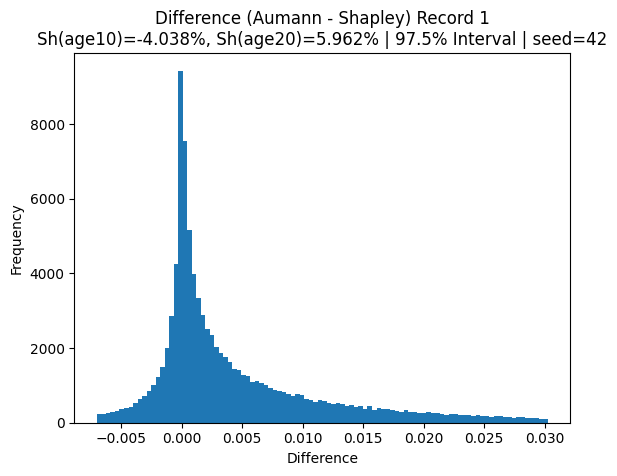


Record 1 example near 97.5% quantile
Difference (record 1) = 0.030260
Prev: [(263.3042902913943, 483.2846157824222), (28.19236152963846, 72.91648072691059)]
Curr: [(15.590209817152598, 26.05450125997233), (143.54634983286678, 266.8393644141191)]

--- Contributions ---
Record 1:
  Shapley         = -0.040380
  Aumann–Shapley  = -0.010120
Record 2 (opposite side):
  Shapley         = 0.059620
  Aumann–Shapley  = 0.029360

--- Simple swap contributions ---
Simple 1→2 contributions: [-8.171, 10.095]
Simple 2→1 contributions: [0.095, 1.829]


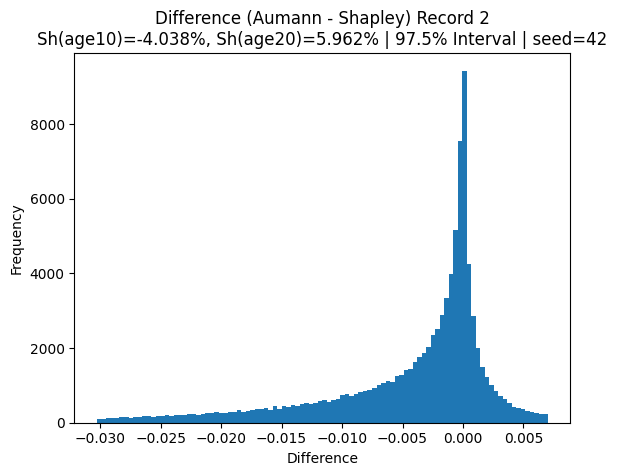


Record 2 example near 97.5% quantile
Difference (record 2) = 0.007016
Prev: [(2.977742910520036, 63.94739032134111), (89.29811167701905, 109.86068445459345)]
Curr: [(89.02704864285809, 256.1801843163546), (309.54041821581325, 468.2948275120716)]

--- Contributions ---
Record 2:
  Shapley         = 0.059620
  Aumann–Shapley  = 0.066636
Record 1 (opposite side):
  Shapley         = -0.040380
  Aumann–Shapley  = -0.047396

--- Simple swap contributions ---
Simple 1→2 contributions: [-4.373, 6.297]
Simple 2→1 contributions: [-3.703, 5.627]


In [1]:
import math
prev=[(2.0e-9, 1e-8), (2.0e-9, 1e-8)]
curr=[(16.924, 100), (26.924, 100)]

def R(ps): 
    return sum(n for n,_ in ps)/sum(d for _,d in ps)

def simple(order):
    p=list(prev); r=R(p); c=[0.0,0.0]
    for i in order:
        p[i]=curr[i]
        rn=R(p); c[i]=rn-r; r=rn
    return c

s10_20=simple([0,1]); s20_10=simple([1,0])
shap=[(a+b)/2 for a,b in zip(s10_20,s20_10)]

Np,Dp=map(sum,zip(*prev)); Nc,Dc=map(sum,zip(*curr))
dN,dD=Nc-Np,Dc-Dp
s=dN/dD; C=Np-s*Dp
log=math.log(Dc/Dp); common=C*(1/Dp-1/Dc)+s*log

aum=[((Nci-Npi)*log-(Dci-Dpi)*common)/dD for (Npi,Dpi),(Nci,Dci) in zip(prev,curr)]

print({
    "simple 10→20":[round(100*x,3) for x in s10_20],
    "simple 20→10":[round(100*x,3) for x in s20_10],
    "Shapley":[round(100*x,3) for x in shap],
    "Aumann":[round(100*x,3) for x in aum]
})

#=========================================
import random
import math
import numpy as np
import matplotlib.pyplot as plt

N_SIM = 100_000
SEED = 42

target_sh0 = -4.038 / 100
target_sh1 =  5.962 / 100

random.seed(SEED)
np.random.seed(SEED)

def R(ps):
    return sum(n for n, _ in ps) / sum(d for _, d in ps)

def simple(prev, curr, order):
    p = list(prev)
    r = R(p)
    c = [0.0, 0.0]
    for i in order:
        p[i] = curr[i]
        rn = R(p)
        c[i] = rn - r
        r = rn
    return c

def shapley(prev, curr):
    s01 = simple(prev, curr, [0, 1])
    s10 = simple(prev, curr, [1, 0])
    return [(a + b) / 2 for a, b in zip(s01, s10)]

def aumann(prev, curr):
    Np, Dp = map(sum, zip(*prev))
    Nc, Dc = map(sum, zip(*curr))
    dN, dD = Nc - Np, Dc - Dp
    if dD == 0:
        return [0.0, 0.0]
    s = dN / dD
    C = Np - s * Dp
    log = math.log(Dc / Dp)
    common = C * (1 / Dp - 1 / Dc) + s * log
    return [((Nci - Npi) * log - (Dci - Dpi) * common) / dD
            for (Npi, Dpi), (Nci, Dci) in zip(prev, curr)]

def gen_year_with_two_targets(target_sh0, target_sh1, max_tries=10):
    for _ in range(max_tries):
        Dp = [random.uniform(0, 500) for _ in range(2)]
        Dc = [random.uniform(0, 500) for _ in range(2)]
        rp = [random.random() for _ in range(2)]
        Np = [rp[i] * Dp[i] for i in range(2)]

        Rp = (Np[0] + Np[1]) / (Dp[0] + Dp[1])
        target_delta = target_sh0 + target_sh1
        target_Rc = Rp + target_delta

        def y_from_x(x):
            return target_Rc * (Dc[0] + Dc[1]) - x

        def sh0_of_x(x):
            y = y_from_x(x)
            if y < 0 or y > Dc[1]:
                return None
            prev = [(Np[0], Dp[0]), (Np[1], Dp[1])]
            curr = [(x, Dc[0]), (y, Dc[1])]
            return shapley(prev, curr)[0]

        lo, hi = 0.0, Dc[0]
        f_lo = sh0_of_x(lo)
        f_hi = sh0_of_x(hi)
        if f_lo is None or f_hi is None:
            continue

        f_lo -= target_sh0
        f_hi -= target_sh0
        if f_lo * f_hi > 0:
            continue

        for _ in range(50):
            mid = (lo + hi) / 2
            f_mid = sh0_of_x(mid)
            if f_mid is None:
                hi = mid
                continue
            f_mid -= target_sh0
            if f_lo * f_mid <= 0:
                hi, f_hi = mid, f_mid
            else:
                lo, f_lo = mid, f_mid

        x = (lo + hi) / 2
        y = y_from_x(x)

        prev = [(Np[0], Dp[0]), (Np[1], Dp[1])]
        curr = [(x, Dc[0]), (y, Dc[1])]
        return prev, curr

    return None

diffs = [[], []]
records = [[], []]

count = 0
while count < N_SIM:
    pair = gen_year_with_two_targets(target_sh0, target_sh1)
    if pair is None:
        continue
    prev, curr = pair
    sh = shapley(prev, curr)
    au = aumann(prev, curr)
    s01 = simple(prev, curr, [0,1])
    s10 = simple(prev, curr, [1,0])
    for i in range(2):
        diff = au[i] - sh[i]
        diffs[i].append(diff)
        records[i].append((diff, prev, curr, sh[i], au[i], s01, s10))
    count += 1

for i in range(2):
    arr = np.array(diffs[i])
    lo, hi = np.percentile(arr, [2.5, 97.5])

    plt.figure()
    plt.hist(arr, bins=100, range=(lo, hi))
    plt.title(
        f"Difference (Aumann - Shapley) Record {i+1}\n"
        f"Sh(age10)={target_sh0*100:.3f}%, "
        f"Sh(age20)={target_sh1*100:.3f}% | 97.5% Interval | seed={SEED}"
    )
    plt.xlabel("Difference")
    plt.ylabel("Frequency")
    plt.show()

    closest = min(records[i], key=lambda x: abs(x[0] - hi))
    diff, prev_ex, curr_ex, sh_ex, au_ex, s01_ex, s10_ex = closest

    j = 1 - i

    sh_all = shapley(prev_ex, curr_ex)
    au_all = aumann(prev_ex, curr_ex)

    print(f"\nRecord {i+1} example near 97.5% quantile")
    print(f"Difference (record {i+1}) = {diff:.6f}")
    print("Prev:", prev_ex)
    print("Curr:", curr_ex)

    print("\n--- Contributions ---")
    print(f"Record {i+1}:")
    print(f"  Shapley         = {sh_all[i]:.6f}")
    print(f"  Aumann–Shapley  = {au_all[i]:.6f}")

    print(f"Record {j+1} (opposite side):")
    print(f"  Shapley         = {sh_all[j]:.6f}")
    print(f"  Aumann–Shapley  = {au_all[j]:.6f}")

    print("\n--- Simple swap contributions ---")
    print(f"Simple 1→2 contributions: {[round(100*x,3) for x in s01_ex]}")
    print(f"Simple 2→1 contributions: {[round(100*x,3) for x in s10_ex]}")

### Table6

In [7]:
import math
prev=[(2.0e-9, 1e-8), (2.0e-9, 1e-8)]
curr=[(16.924, 100), (26.924, 100)]

def R(ps): 
    return sum(n for n,_ in ps)/sum(d for _,d in ps)

def simple(order):
    p=list(prev); r=R(p); c=[0.0,0.0]
    for i in order:
        p[i]=curr[i]
        rn=R(p); c[i]=rn-r; r=rn
    return c

s10_20=simple([0,1]); s20_10=simple([1,0])
shap=[(a+b)/2 for a,b in zip(s10_20,s20_10)]

Np,Dp=map(sum,zip(*prev)); Nc,Dc=map(sum,zip(*curr))
dN,dD=Nc-Np,Dc-Dp
s=dN/dD; C=Np-s*Dp
log=math.log(Dc/Dp); common=C*(1/Dp-1/Dc)+s*log

aum=[((Nci-Npi)*log-(Dci-Dpi)*common)/dD for (Npi,Dpi),(Nci,Dci) in zip(prev,curr)]

{
    "simple 10→20":[round(100*x,3) for x in s10_20],
    "simple 20→10":[round(100*x,3) for x in s20_10],
    "Shapley":[round(100*x,3) for x in shap],
    "Aumann":[round(100*x,3) for x in aum]
}


{'simple 10→20': [-3.076, 5.0],
 'simple 20→10': [-5.0, 6.924],
 'Shapley': [-4.038, 5.962],
 'Aumann': [-56.603, 58.527]}

### image 1, 4, 5, 7

Please show examples\example1.ipynb

### Table 8

In [8]:
import math

import pandas as pd
import pysubgroup as ps


# Small dataset for a paper example
DATA = [
    {"Product": "A", "age": 10, "impact": -50},
    {"Product": "A", "age": 20, "impact": -50},
    {"Product": "B", "age": 10, "impact": 50},
    {"Product": "B", "age": 20, "impact": -20},
    {"Product": "B", "age": 30, "impact": -45},
]

ATOMIC_CONDS = [
    ("Product", "A"),
    ("Product", "B"),
    ("age", 10),
    ("age", 20),
    ("age", 30),
]

ALPHA = 0.5


def beam_search_abs(
    data,
    atomic_conds,
    alpha,
    beam_width=2,
    max_depth=2,
):
    n = len(data)
    mu = sum(row["impact"] for row in data) / n

    def indices_for(subgroup):
        return [
            i
            for i, row in enumerate(data)
            if all(row[key] == value for key, value in subgroup)
        ]

    def q_abs(indices):
        if not indices:
            return 0.0

        mu_g = (
            sum(data[i]["impact"] for i in indices)
            / len(indices)
        )

        return (
            (len(indices) / n) ** alpha
            * abs(mu_g - mu)
        )

    def expand(subgroup):
        for cond in atomic_conds:
            if cond in subgroup:
                continue

            # Do not allow contradictory conditions such as
            # Product == "A" and Product == "B".
            if any(
                key == cond[0] and value != cond[1]
                for key, value in subgroup
            ):
                continue

            new_subgroup = subgroup + [cond]
            indices = indices_for(new_subgroup)

            if indices:
                yield new_subgroup, indices, q_abs(indices)

    results = []

    for cond in atomic_conds:
        indices = indices_for([cond])
        results.append(([cond], indices, q_abs(indices)))

    print("=== depth 1 (all candidates) ===")

    for subgroup, indices, score in sorted(
        results,
        key=lambda item: item[2],
        reverse=True,
    ):
        print(f"{subgroup} -> Q={score:.3f}")

    beam = sorted(
        results,
        key=lambda item: item[2],
        reverse=True,
    )[:beam_width]

    print("\nbeam =", [subgroup for subgroup, _, _ in beam])

    for depth in range(2, max_depth + 1):
        candidates = []

        for subgroup, _, _ in beam:
            candidates.extend(expand(subgroup))

        candidates.extend(beam)
        candidates.sort(
            key=lambda item: item[2],
            reverse=True,
        )

        print(f"\n=== depth {depth} (all candidates) ===")

        for subgroup, indices, score in candidates:
            print(f"{subgroup} -> Q={score:.3f}")

        beam = candidates[:beam_width]

        print(f"\n=== depth {depth} ===")

        for subgroup, indices, score in beam:
            print(f"{subgroup} -> Q={score:.3f}")

    return beam


class AbsStdQFNumeric(ps.BoundedInterestingnessMeasure):
    """Absolute-value wrapper for StandardQFNumeric."""

    def __init__(self, a=1.0, invert=False, estimator="sum"):
        self.base = ps.StandardQFNumeric(
            a=a,
            invert=invert,
            estimator=estimator,
        )

    def calculate_constant_statistics(self, data, target):
        self.base.calculate_constant_statistics(data, target)

    def calculate_statistics(
        self,
        subgroup,
        target,
        data,
        statistics=None,
    ):
        return self.base.calculate_statistics(
            subgroup,
            target,
            data,
            statistics,
        )

    def evaluate(
        self,
        subgroup,
        target,
        data,
        statistics=None,
    ):
        return abs(
            self.base.evaluate(
                subgroup,
                target,
                data,
                statistics,
            )
        )

    def optimistic_estimate(
        self,
        subgroup,
        target,
        data,
        statistics=None,
    ):
        return abs(
            self.base.optimistic_estimate(
                subgroup,
                target,
                data,
                statistics,
            )
        )


def sg_sig_manual(subgroup):
    return tuple(
        sorted(
            subgroup,
            key=lambda condition: (
                condition[0],
                condition[1],
            ),
        )
    )


def sg_sig_ps(subgroup):
    return tuple(
        sorted(
            (
                selector.attribute_name,
                selector.attribute_value,
            )
            for selector in subgroup.selectors
        )
    )


def main():
    manual = beam_search_abs(
        DATA,
        ATOMIC_CONDS,
        ALPHA,
        beam_width=2,
        max_depth=2,
    )

    manual = [
        (sg_sig_manual(subgroup), score)
        for subgroup, _, score in manual
    ]

    df = pd.DataFrame(DATA)
    target = ps.NumericTarget("impact")

    qf = AbsStdQFNumeric(
        a=ALPHA,
        estimator="sum",
    )

    search_space = [
        ps.EqualitySelector(key, value)
        for key, value in ATOMIC_CONDS
    ]

    task = ps.SubgroupDiscoveryTask(
        df,
        target,
        search_space,
        qf,
        result_set_size=2,
        depth=2,
    )

    result = ps.BeamSearch(
        beam_width=2,
    ).execute(task)

    ps_out = [
        (
            sg_sig_ps(subgroup),
            quality / (len(DATA) ** ALPHA),
        )
        for quality, subgroup, _ in result.results
    ]

    print("manual:", manual)
    print("pysubgroup:", ps_out)

    if not all(
        manual_item[0] == ps_item[0]
        and math.isclose(
            manual_item[1],
            ps_item[1],
            rel_tol=1e-9,
            abs_tol=1e-12,
        )
        for manual_item, ps_item in zip(manual, ps_out)
    ):
        raise AssertionError(
            "Mismatch between manual and pysubgroup results."
        )


if __name__ == "__main__":
    main()

=== depth 1 (all candidates) ===
[('Product', 'A')] -> Q=17.076
[('age', 10)] -> Q=14.546
[('Product', 'B')] -> Q=13.943
[('age', 30)] -> Q=9.839
[('age', 20)] -> Q=7.589

beam = [[('Product', 'A')], [('age', 10)]]

=== depth 2 (all candidates) ===
[('age', 10), ('Product', 'B')] -> Q=32.647
[('Product', 'A')] -> Q=17.076
[('age', 10)] -> Q=14.546
[('Product', 'A'), ('age', 10)] -> Q=12.075
[('Product', 'A'), ('age', 20)] -> Q=12.075
[('age', 10), ('Product', 'A')] -> Q=12.075

=== depth 2 ===
[('age', 10), ('Product', 'B')] -> Q=32.647
[('Product', 'A')] -> Q=17.076
manual: [((('Product', 'B'), ('age', 10)), 32.64659247149693), ((('Product', 'A'),), 17.07629936490925)]
pysubgroup: [((('Product', 'B'), ('age', 10)), 32.64659247149693), ((('Product', 'A'),), 17.07629936490925)]


### image 8

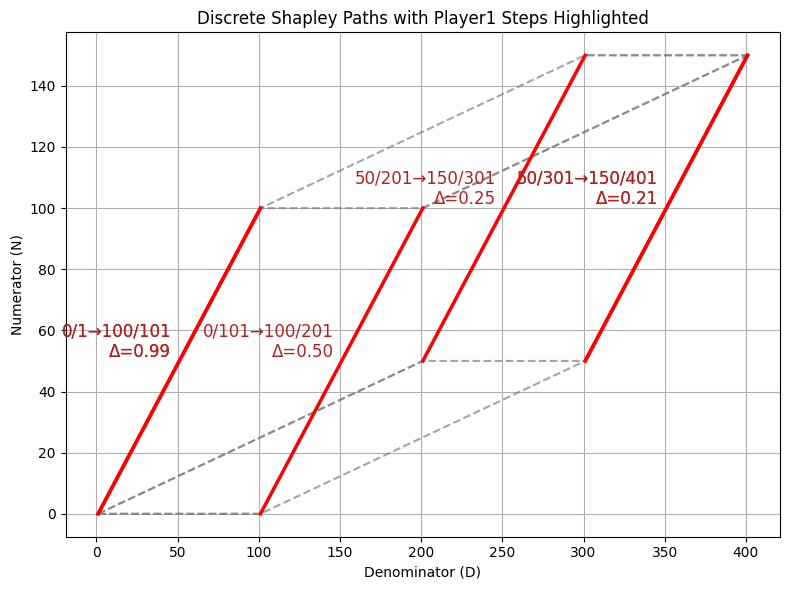

In [2]:
import matplotlib.pyplot as plt
import itertools
import numpy as np

# プレイヤーの変更量 (分子, 分母)
players = [(100, 100), (0, 100), (50, 200)]
start = (0, 1)

# 経路生成（全順列）
paths = []
for perm in itertools.permutations(range(3)):
    N, D = start
    path = [(N, D)]
    for p in perm:
        N += players[p][0]
        D += players[p][1]
        path.append((N, D))
    paths.append(path)

# 描画
plt.figure(figsize=(8, 6))
for path in paths:
    xs, ys = zip(*path)
    plt.plot(ys, xs, linestyle="--", color="gray", alpha=0.7)

# プレイヤー1の動作を赤線で強調
for path in paths:
    for i in range(1, len(path)):
        prev, cur = path[i-1], path[i]
        # プレイヤー1の動作（100,100）のステップのみ赤
        if abs(cur[0]-prev[0]) == 100 and abs(cur[1]-prev[1]) == 100:
            plt.plot([prev[1], cur[1]], [prev[0], cur[0]], color="red", linewidth=2.5)
            # テキスト: 分母/分子の移動 & 限界効用 (比率差)
            r_before = prev[0]/prev[1]
            r_after = cur[0]/cur[1]
            diff = r_after - r_before
            label = f"{prev[0]}/{prev[1]}→{cur[0]}/{cur[1]}\nΔ={diff:.2f}"
            # ← 位置を左に少しずらす
            plt.text((prev[1]+cur[1])/2 - 5, (prev[0]+cur[0])/2, label,
                     fontsize=12, ha="right", va="bottom", color="firebrick")

# 軸ラベル
plt.xlabel("Denominator (D)")
plt.ylabel("Numerator (N)")
plt.title("Discrete Shapley Paths with Player1 Steps Highlighted")
plt.grid(True)
plt.tight_layout()
plt.show()


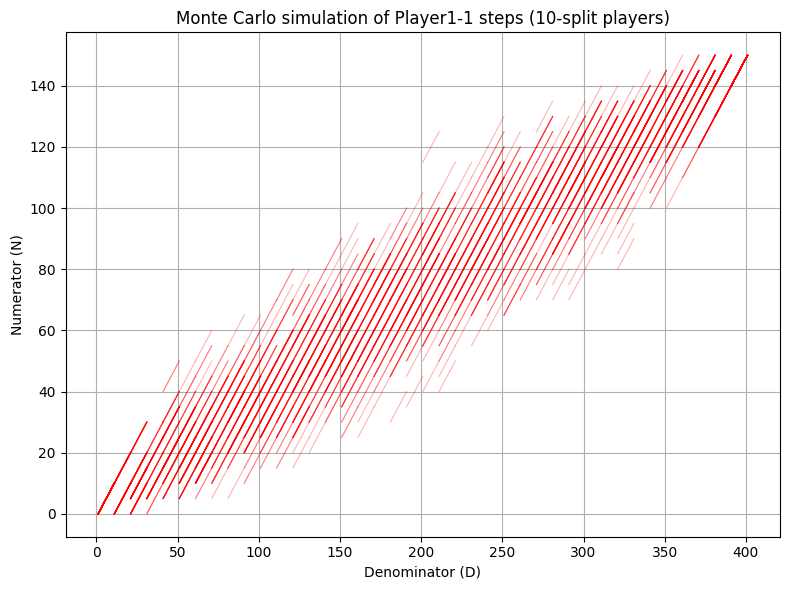

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import random

# 元のプレイヤーの変更量 (分子, 分母)
players = [(100, 100), (0, 100), (50, 200)]
start = (0, 1)

# プレイヤーを100分割
split_n = 10
split_players = []
for N, D in players:
    dN, dD = N / split_n, D / split_n
    split_players.extend([(dN, dD)] * split_n)

# プレイヤー1-1の増分
p1_increment = (players[0][0] / split_n, players[0][1] / split_n)

# Monte Carloシミュレーション
n_simulations = 3000
random_points = []
for _ in range(n_simulations):
    # プレイヤー1-1以外の299プレイヤーからランダム選択
    subset = random.sample(split_players[1:], random.randint(0, len(split_players) - 1))
    N = start[0] + sum(p[0] for p in subset)
    D = start[1] + sum(p[1] for p in subset)
    random_points.append((N, D))

# プロット
plt.figure(figsize=(8, 6))
# モンテカルロ発射点
for (N, D) in random_points:
    plt.plot([D, D + p1_increment[1]], [N, N + p1_increment[0]], color="red", linewidth=0.8, alpha=0.3)

plt.xlabel("Denominator (D)")
plt.ylabel("Numerator (N)")
plt.title(f"Monte Carlo simulation of Player1-1 steps ({split_n}-split players)")
plt.grid(True)
plt.tight_layout()
plt.show()


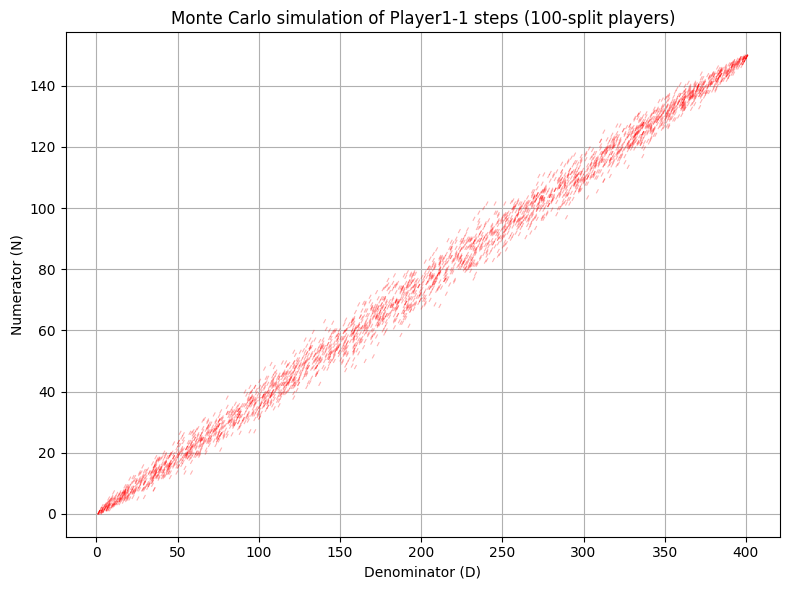

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import random

# 元のプレイヤーの変更量 (分子, 分母)
players = [(100, 100), (0, 100), (50, 200)]
start = (0, 1)

# プレイヤーを100分割
split_n = 100
split_players = []
for N, D in players:
    dN, dD = N / split_n, D / split_n
    split_players.extend([(dN, dD)] * split_n)

# プレイヤー1-1の増分
p1_increment = (players[0][0] / split_n, players[0][1] / split_n)

# Monte Carloシミュレーション
n_simulations = 3000
random_points = []
for _ in range(n_simulations):
    # プレイヤー1-1以外の299プレイヤーからランダム選択
    subset = random.sample(split_players[1:], random.randint(0, len(split_players) - 1))
    N = start[0] + sum(p[0] for p in subset)
    D = start[1] + sum(p[1] for p in subset)
    random_points.append((N, D))

# プロット
plt.figure(figsize=(8, 6))
# モンテカルロ発射点
for (N, D) in random_points:
    plt.plot([D, D + p1_increment[1]], [N, N + p1_increment[0]], color="red", linewidth=0.8, alpha=0.3)

plt.xlabel("Denominator (D)")
plt.ylabel("Numerator (N)")
plt.title(f"Monte Carlo simulation of Player1-1 steps ({split_n}-split players)")
plt.grid(True)
plt.tight_layout()
plt.show()


### Other Images for Presentation

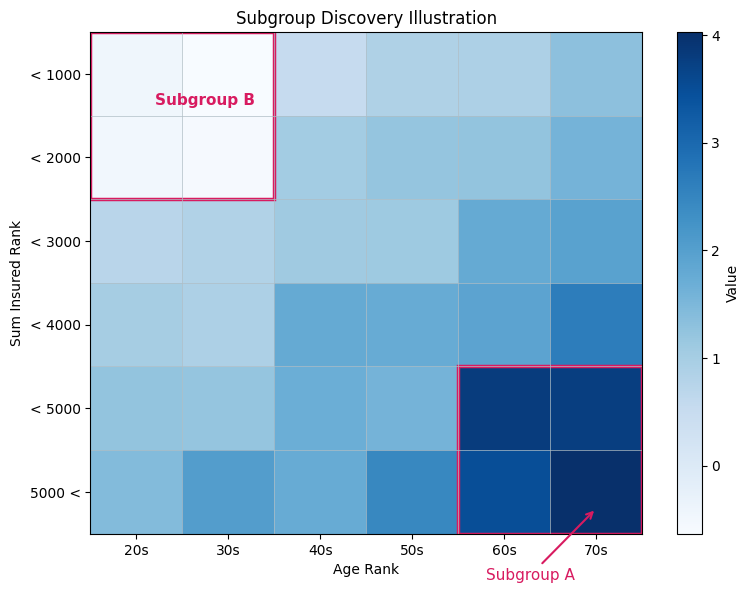

Saved figure -> subgroup_discovery_blue_fixed.png


In [5]:
# Subgroup Discovery illustration (single-chart)
# - Blue tone to match presentation
# - Subgroup A: bottom-right (high values)
# - Subgroup B: top-left (low values)
# - "Subgroup B" label placed inside its rectangle for visibility

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ---------------- Config (edit freely) ----------------
np.random.seed(7)
cmap_name = "Blues"            # heatmap color
grid_color = "#B0BEC5"         # light grid lines
accent = "#D81B60"             # accent color for rectangles/labels
title = "Subgroup Discovery Illustration"
outfile = "subgroup_discovery_blue_fixed.png"
# -----------------------------------------------------

# Axes categories
age_ranks = ["20s","30s","40s","50s","60s","70s"]                    # X
benefit_ranks = ["< 1000","< 2000","< 3000","< 4000","< 5000","5000 <"]  # Y

# Synthetic data with smooth trend + noise
base = np.add.outer(np.linspace(0, 1.2, len(benefit_ranks)),
                    np.linspace(0, 1.0, len(age_ranks)))
noise = 0.20 * np.random.randn(len(benefit_ranks), len(age_ranks))
Z = 1.3 * base + noise

# Emphasize two regions:
# A: bottom-right (high)
y_br0, y_br1 = benefit_ranks.index("< 5000"), benefit_ranks.index("5000 <")
x_br0, x_br1 = age_ranks.index("60s"), age_ranks.index("70s")
Z[y_br0:y_br1+1, x_br0:x_br1+1] += 1.3

# B: top-left (low)
y_tl0, y_tl1 = benefit_ranks.index("< 1000"), benefit_ranks.index("< 2000")
x_tl0, x_tl1 = age_ranks.index("20s"), age_ranks.index("30s")
Z[y_tl0:y_tl1+1, x_tl0:x_tl1+1] -= 0.8

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(Z, aspect="auto", cmap=cmap_name)

# Ticks / labels
ax.set_xticks(range(len(age_ranks)))
ax.set_xticklabels(age_ranks)
ax.set_yticks(range(len(benefit_ranks)))
ax.set_yticklabels(benefit_ranks)
ax.set_xlabel("Age Rank")
ax.set_ylabel("Sum Insured Rank")
ax.set_title(title)

# Subtle grid
for x in range(len(age_ranks)+1):
    ax.axvline(x-0.5, linewidth=0.5, color=grid_color)
for y in range(len(benefit_ranks)+1):
    ax.axhline(y-0.5, linewidth=0.5, color=grid_color)

# Rectangles and annotations
# Subgroup A (bottom-right)
rectA = Rectangle((x_br0-0.5, y_br0-0.5), (x_br1-x_br0+1), (y_br1-y_br0+1),
                  fill=False, linewidth=2.5, edgecolor=accent)
ax.add_patch(rectA)
ax.annotate("Subgroup A",
            xy=(x_br0+(x_br1-x_br0+1)/2, y_br1+0.2),
            xytext=(x_br0-0.2, y_br1+1.0),
            arrowprops=dict(arrowstyle="->", linewidth=1.5, color=accent),
            ha="left", va="center", fontsize=11, color=accent)

# Subgroup B (top-left; label inside the box)
rectB = Rectangle((x_tl0-0.5, y_tl0-0.5), (x_tl1-x_tl0+1), (y_tl1-y_tl0+1),
                  fill=False, linewidth=2.5, edgecolor=accent)
ax.add_patch(rectB)
ax.text(x_tl0+0.2, y_tl0+0.4, "Subgroup B",
        color=accent, fontsize=11, ha="left", va="bottom", weight="bold")

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Value")

plt.tight_layout()
plt.savefig(outfile, dpi=200)
plt.show()

print(f"Saved figure -> {outfile}")


[]

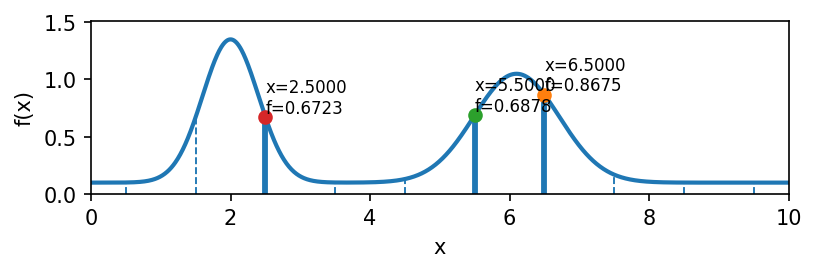

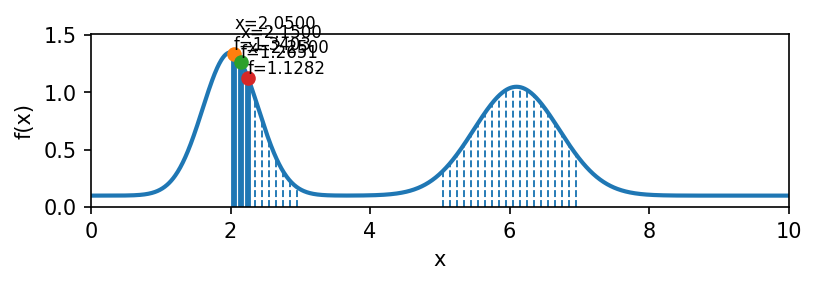

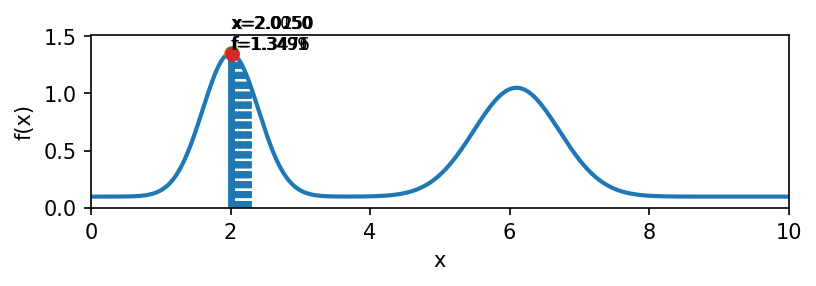

In [12]:
# Generate three static PNGs (STEP 0, 1, 2), no titles.
# - Domain: [0, 10]
# - STEP 0 probes at 0.5, 1.5, ..., 9.5 (10 points). Keep global top-3
# - STEP 1..2: for each kept point, subdivide its parent interval into 10, probe midpoints, keep global top-3
# - f(x) lifted by +0.1
# - Wide aspect (3:1), matplotlib only, single plot per image, no explicit colors

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def f_base(x: np.ndarray) -> np.ndarray:
    return 1.25*np.exp(-((x-2.0)**2)/0.32) + 0.95*np.exp(-((x-6.1)**2)/0.75)

def f(x: np.ndarray) -> np.ndarray:
    return f_base(x) + 0.1

xmin, xmax = 0.0, 10.0
beam_width = 3
subdiv = 10
max_step = 2
init_bins = 10

def step_width(step: int) -> float:
    return (xmax - xmin) / (init_bins * (subdiv**max(0, step)))

def parent_interval_bounds(x: float, step: int) -> tuple[float, float]:
    w = step_width(step)
    lo = max(xmin, x - 0.5*w)
    hi = min(xmax, x + 0.5*w)
    return float(np.round(lo, 10)), float(np.round(hi, 10))

def probe_midpoints(lo: float, hi: float, subdiv: int) -> np.ndarray:
    w = (hi - lo) / subdiv
    ks = np.arange(subdiv, dtype=float) + 0.5
    return lo + ks*w

def topk_idxs(y: np.ndarray, k: int) -> np.ndarray:
    return np.argsort(y)[::-1][:k]

# STEP 0
w0 = (xmax - xmin) / init_bins
step0_probes = np.linspace(xmin + 0.5*w0, xmax - 0.5*w0, init_bins)
step0_vals = f(step0_probes)
keep_idx = topk_idxs(step0_vals, beam_width)
kept_x = step0_probes[keep_idx]
kept_y = step0_vals[keep_idx]

trace = [{
    "probes": step0_probes.copy(),
    "values": step0_vals.copy(),
    "kept": kept_x.copy(),
    "kept_vals": kept_y.copy()
}]

# STEPs 1..2
for s in range(1, max_step+1):
    all_probes = []
    for x0 in trace[-1]["kept"]:
        lo, hi = parent_interval_bounds(x0, s-1)
        xs = probe_midpoints(lo, hi, subdiv)
        all_probes.append(xs)
    probes = np.unique(np.concatenate(all_probes))
    values = f(probes)
    keep_idx = topk_idxs(values, beam_width)
    kept_x = probes[keep_idx]
    kept_y = values[keep_idx]
    trace.append({
        "probes": probes.copy(),
        "values": values.copy(),
        "kept": kept_x.copy(),
        "kept_vals": kept_y.copy()
    })

# Render PNGs without titles
xx = np.linspace(xmin, xmax, 1400)
yy = f(xx)
ymin, ymax = 0.0, float(np.max(yy)*1.12)

out_files = []
for step, rec in enumerate(trace):
    probes = rec["probes"]
    values = rec["values"]
    kept = rec["kept"]
    kept_vals = rec["kept_vals"]

    fig, ax = plt.subplots(figsize=(6, 1.5), dpi=150)  # 3:1
    ax.plot(xx, yy, linewidth=2.0)  # base curve

    # probes (thin dashed)
    for x in probes:
        ax.vlines(x, ymin, float(f(np.array([x]))[0]), linestyles="dashed", linewidth=0.9)

    # kept (thicker + marker + label)
    for x, y in zip(kept, kept_vals):
        ax.vlines(x, ymin, y, linewidth=2.8)
        ax.plot([x], [y], marker="o")
        ax.text(x, y, f"x={x:.4f}\nf={y:.4f}", fontsize=8, ha="left", va="bottom")

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")


out_files
